In [ ]:
import pandas as pd
import numpy as np
from libsvm.svmutil import *

specie='albopictus'
full_specie_name='Aedes'+' '+specie
quantile=75
quantile_value=quantile/100

year=2015
if year>2015:
    model_name='ocsvm_'+specie+'_median_parameters_quantile_'+str(quantile)+'_'+str(year-1)+'.model'
else:
    model_name='ocsvm_'+specie+'_median_parameters_quantile_'+str(quantile)+'.model'
m=svm_load_model(model_name)

data=pd.read_csv('mosquito_climate_pop_land_use_n.csv',low_memory=False)
start_index_t2m=data.columns.get_loc('t2m_1')
start_index_d2m=data.columns.get_loc('d2m_1')
start_index_tp=data.columns.get_loc('tp_1')
start_index_si10=data.columns.get_loc('si10_1')

t2m_mean=data.iloc[:,start_index_t2m:start_index_t2m+12].quantile(quantile_value,axis=1)
d2m_mean=data.iloc[:,start_index_d2m:start_index_d2m+12].quantile(quantile_value,axis=1)
tp_mean=data.iloc[:,start_index_tp:start_index_tp+12].quantile(quantile_value,axis=1)
si10_mean=data.iloc[:,start_index_si10:start_index_si10+12].quantile(quantile_value,axis=1)


data.insert(1,'t2m_mean',t2m_mean)
data.insert(2,'d2m_mean',d2m_mean)
data.insert(3,'tp_mean',tp_mean)
data.insert(4,'si10_mean',si10_mean)
data["Target_Class"]=1

df=data[data["VECTOR"]==full_specie_name]
#df_aegypti=df.drop(['Unnamed: 0','VECTOR','OCCURRENCE_ID','SOURCE_TYPE','LOCATION_TYPE','POLYGON_ADMIN','Y','X','COUNTRY','COUNTRY_ID','GAUL_AD0','STATUS','Population_Density','land_use_0','land_use_11','land_use_22','land_use_33','land_use_44','land_use_55','land_use_66','land_use_77'],axis=1)
#df_aegypti=df.drop(['Unnamed: 0','VECTOR','OCCURRENCE_ID','SOURCE_TYPE','LOCATION_TYPE','POLYGON_ADMIN','YEAR','Y','X','COUNTRY','COUNTRY_ID','GAUL_AD0','STATUS'],axis=1)
#columns_list=['t2m_mean', 'd2m_mean', 'tp_mean', 'si10_mean','Y','X','Population_Density', 'land_use_0', 'land_use_11',
#    'land_use_22', 'land_use_33', 'land_use_44', 'land_use_55',
#    'land_use_66', 'land_use_77','Target_Class'] # can/add remove Y,X from here
columns_list=['t2m_mean', 'd2m_mean', 'tp_mean', 'si10_mean','Population_Density', 'land_use_0', 'land_use_11',
    'land_use_22', 'land_use_33', 'land_use_44', 'land_use_55',
    'land_use_66', 'land_use_77','Target_Class'] # can/add remove Y,X from here
df_aegypti=df.loc[:,columns_list]
df_aegypti=df_aegypti.dropna()
#df_aegypti=df_aegypti[df_aegypti['Population_Density']>0]
X=df_aegypti.drop('Target_Class',axis=1)
y=df_aegypti['Target_Class']
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=2)
cols=X_train.columns
from sklearn.preprocessing import StandardScaler
#from sklearn.preprocessing import PowerTransformer
scaler=StandardScaler()
#scaler = PowerTransformer(method='yeo-johnson', standardize=True)  # Default: Yeo-Johnson and standardize=True
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)
X_train=pd.DataFrame(X_train,columns=[cols])
X_test=pd.DataFrame(X_test,columns=[cols])





In [5]:
csv_filename=str(year)+'_GMOD_'+specie+'_climate_data_subset_pop_den_land_use_lat_lon.csv'
df_GMOD=pd.read_csv(csv_filename)
df_GMOD = df_GMOD.rename(columns={'t2m': 't2m_mean', 'd2m': 'd2m_mean','tp':'tp_mean','si10':'si10_mean'})
df_GMOD['Target_Class']=-1
df_GMOD=df_GMOD.drop(['Unnamed: 0'],axis=1)
df_GMOD_pop=df_GMOD.copy()
df_GMOD_pop=df_GMOD_pop.dropna()
lat_test_data=df_GMOD_pop['latitude'].copy()
lon_test_data=df_GMOD_pop['longitude'].copy()
geometry_test_data=df_GMOD_pop['geometry'].copy()
X_test_apparent=df_GMOD_pop.drop(['year','Target_Class','geometry'],axis=1)
y_test_apparent=df_GMOD_pop['Target_Class']
val_columns_list=['t2m_mean', 'd2m_mean', 'tp_mean', 'si10_mean','Population_Density', 'land_use_0', 'land_use_11',
            'land_use_22', 'land_use_33', 'land_use_44', 'land_use_55',
            'land_use_66', 'land_use_77']
X_test_apparent=X_test_apparent.loc[:,val_columns_list]
X_test_transform=scaler.transform(X_test_apparent)
X_test_apparent_original=scaler.inverse_transform(X_test_transform)
X_test_apparent_original=pd.DataFrame(X_test_apparent_original,columns=[cols])
X_test_apparent_original['Y']=lat_test_data.values
X_test_apparent_original['X']=lon_test_data.values
X_test_apparent_original['geometry']=geometry_test_data.values
#X_test_apparent_original['Target_Class_Prediction']=y_pred_apparent
#y_test=y_test.values.tolist()
X_test_transform=X_test_transform.tolist()
p_label, p_acc, p_dec = svm_predict([], X_test_transform, m, '-b 0')
p_label, p_acc, p_val = svm_predict([], X_test_transform, m, '-b 1')





Model supports probability estimates, but disabled in predicton.
Accuracy = 0% (0/1090) (classification)
Accuracy = 0% (0/1090) (classification)


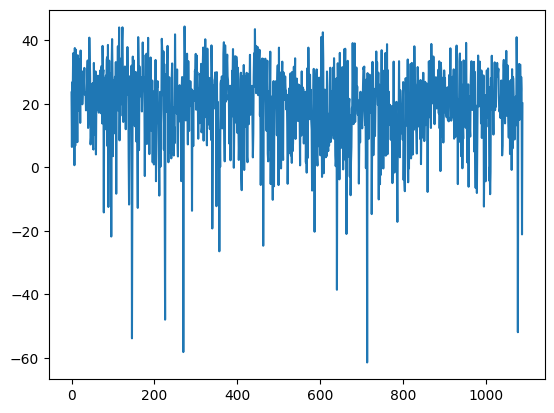

In [6]:
import matplotlib.pyplot as plt
plt.plot(p_dec)
plt.show()

In [7]:
df_prob=pd.DataFrame({'Latitude':lat_test_data.values,'Longitude':lon_test_data.values})
df_prob['geometry']=geometry_test_data.values
df_prob_new=pd.DataFrame(p_val,columns=['Prob_1', 'Prob_2'])
df_prob_new['P_Label']=p_label
combined_df=pd.concat([df_prob,df_prob_new],axis=1)
df_filtered=combined_df.loc[combined_df['Prob_1']<0.5]
index_list = df_filtered.index.tolist()
print(index_list)

[78, 89, 96, 108, 139, 146, 147, 160, 177, 204, 212, 225, 226, 265, 270, 291, 340, 350, 357, 410, 411, 417, 457, 463, 481, 483, 486, 489, 500, 522, 568, 581, 587, 605, 609, 641, 645, 647, 656, 664, 665, 672, 674, 694, 714, 725, 742, 745, 747, 775, 780, 786, 787, 802, 804, 805, 813, 860, 891, 933, 959, 976, 979, 996, 1000, 1009, 1011, 1012, 1063, 1078, 1088]


In [8]:
filtered_X_test_apparent=X_test_apparent.loc[index_list,:]
if filtered_X_test_apparent.size >0:
    filtered_X_test_transform=scaler.transform(filtered_X_test_apparent)
else:
    filtered_X_test_transform=[]
filtered_X_test_transform

array([[ 2.52162366e+00, -7.74337497e-01, -1.95459162e+00,
        -4.34296710e-01, -7.29139843e-01, -3.94394560e-01,
        -1.29816987e+00, -7.53975258e-01, -2.78557664e-01,
         3.84036593e+00, -3.09668388e-01, -8.90406654e-02,
        -3.78372332e-01],
       [-1.09872857e+00, -7.04297266e-01, -1.42011442e+00,
         1.77616995e-01, -7.23725449e-01,  2.52727552e-01,
        -1.30580808e+00, -7.66352797e-01, -1.85362467e-01,
         2.72605259e+00, -2.73927229e-02,  6.35701664e+00,
        -2.96862510e-01],
       [-3.91190165e+00, -2.87787411e+00, -1.44447271e+00,
        -8.96727685e-01, -7.25133510e-01, -3.94394560e-01,
        -1.22687993e+00, -1.02091529e-01, -3.85066461e-01,
         1.10764512e+00, -1.23486566e-01, -8.90406654e-02,
         6.40324488e+00],
       [-4.05038055e+00, -3.16171124e+00, -1.62856521e+00,
        -4.46553463e-01, -6.86603106e-01, -3.94394560e-01,
        -9.82457257e-01, -5.31179553e-01, -3.85066461e-01,
         1.77977062e+00, -3.33691849e

In [225]:
if year>2015:
    load_filename=str(year-1)+'_GMOD_'+specie+'_quantile_'+str(quantile)+'.npy'
    load_old_data=np.load(load_filename)
    if load_old_data.size>0:
        data_append=np.append(load_old_data,filtered_X_test_transform,axis=0)
        save_filename=str(year)+'_GMOD_'+specie+'_quantile_'+str(quantile)+'.npy'
        np.save(save_filename,data_append)
    else:
        save_filename=str(year)+'_GMOD_'+specie+'_quantile_'+str(quantile)+'.npy'
        np.save(save_filename,filtered_X_test_transform)

else:
    save_filename=str(2015)+'_GMOD_'+specie+'_quantile_'+str(quantile)+'.npy'
    np.save(save_filename,filtered_X_test_transform)


In [ ]:
# Code to add support vectors directly to the model manually
#for i in range(len(filtered_X_test_transform)):
#    keys = (filtered_X_test_transform[i])
#    values = (np.arange(1,14))
#    my_dict = dict(zip(values, keys))
#    output_string = " ".join([f"{key}:{value}" for key, value in my_dict.items()])
#    print("1 "+ output_string)